# GEMM efficiency: vLLM vs AccTTS

Reads `gemm_efficiency_profile.xlsx`, plots a grouped bar chart of GEMM runtime (μs) across beam counts 2..256, with vLLM on the left and AccTTS on the right of each group.

In [1]:
from pathlib import Path
import re
import zipfile
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

XLSX_PATH = Path(
    "./nvidia_toolkit_data/"
    "gemm_efficiency_profile/gemm_efficiency_profile.xlsx"
)
FIGURES_DIR = Path("./figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUT_PNG = FIGURES_DIR / "gemm_efficiency_profile.png"

In [2]:
def _read_xlsx_via_zip(path: Path) -> pd.DataFrame:
    """Stdlib-only xlsx reader; sidesteps the openpyxl dependency."""
    ns = {"s": "http://schemas.openxmlformats.org/spreadsheetml/2006/main"}
    with zipfile.ZipFile(path) as z:
        shared = []
        if "xl/sharedStrings.xml" in z.namelist():
            root = ET.fromstring(z.read("xl/sharedStrings.xml"))
            for si in root.findall("s:si", ns):
                shared.append(
                    "".join(
                        t.text or ""
                        for t in si.iter(
                            "{http://schemas.openxmlformats.org/spreadsheetml/2006/main}t"
                        )
                    )
                )
        sheet_name = next(
            n for n in z.namelist() if n.startswith("xl/worksheets/sheet") and n.endswith(".xml")
        )
        root = ET.fromstring(z.read(sheet_name))
        rows = []
        for row in root.findall(".//s:row", ns):
            cells = {}
            for c in row.findall("s:c", ns):
                ref = c.attrib.get("r", "")
                col_letters = re.match(r"[A-Z]+", ref).group(0)
                idx = 0
                for ch in col_letters:
                    idx = idx * 26 + (ord(ch) - ord("A") + 1)
                idx -= 1
                t = c.attrib.get("t")
                v = c.find("s:v", ns)
                if t == "s" and v is not None:
                    cells[idx] = shared[int(v.text)]
                elif v is not None:
                    cells[idx] = v.text
            if cells:
                rows.append([cells.get(i, "") for i in range(max(cells) + 1)])
    header, *body = rows
    df = pd.DataFrame(body, columns=header).set_index(header[0])
    return df.apply(pd.to_numeric)


def load_data(path: Path) -> pd.DataFrame:
    try:
        df = pd.read_excel(path, index_col=0)
        return df.apply(pd.to_numeric)
    except ImportError:
        return _read_xlsx_via_zip(path)


df = load_data(XLSX_PATH)
df

,2,4,8,16,32,64,128,256
#beams (us),,,,,,,,
vLLM,121.760,141.601,141.312,124.384,130.688,136.192,150.977,199.361
AccTTS,113.761,113.888,114.593,115.489,121.409,129.920,150.208,195.842


In [13]:
# ---- Plot configuration (tweak these knobs) ----
BAR_WIDTH = 0.35       # width of each individual bar
BAR_GAP = 0.05         # horizontal gap between the two bars inside a group
GROUP_GAP = 0.45       # horizontal gap between neighboring groups

FONTSIZE = 14          # one knob for everything per request
FONTSIZE_XLABEL = FONTSIZE
FONTSIZE_YLABEL = FONTSIZE
FONTSIZE_XTICKS = FONTSIZE
FONTSIZE_YTICKS = FONTSIZE
FONTSIZE_XTITLE = FONTSIZE
FONTSIZE_YTITLE = FONTSIZE
FONTSIZE_LEGEND = FONTSIZE

COLOR_VLLM = "#ff9aa7"
COLOR_ACCTTS = "#9fd564"

Y_RANGE = (100, 205)
FIG_SIZE = (9, 3)
FIG_DPI = 300

saved -> ./figures/gemm_efficiency_profile.png


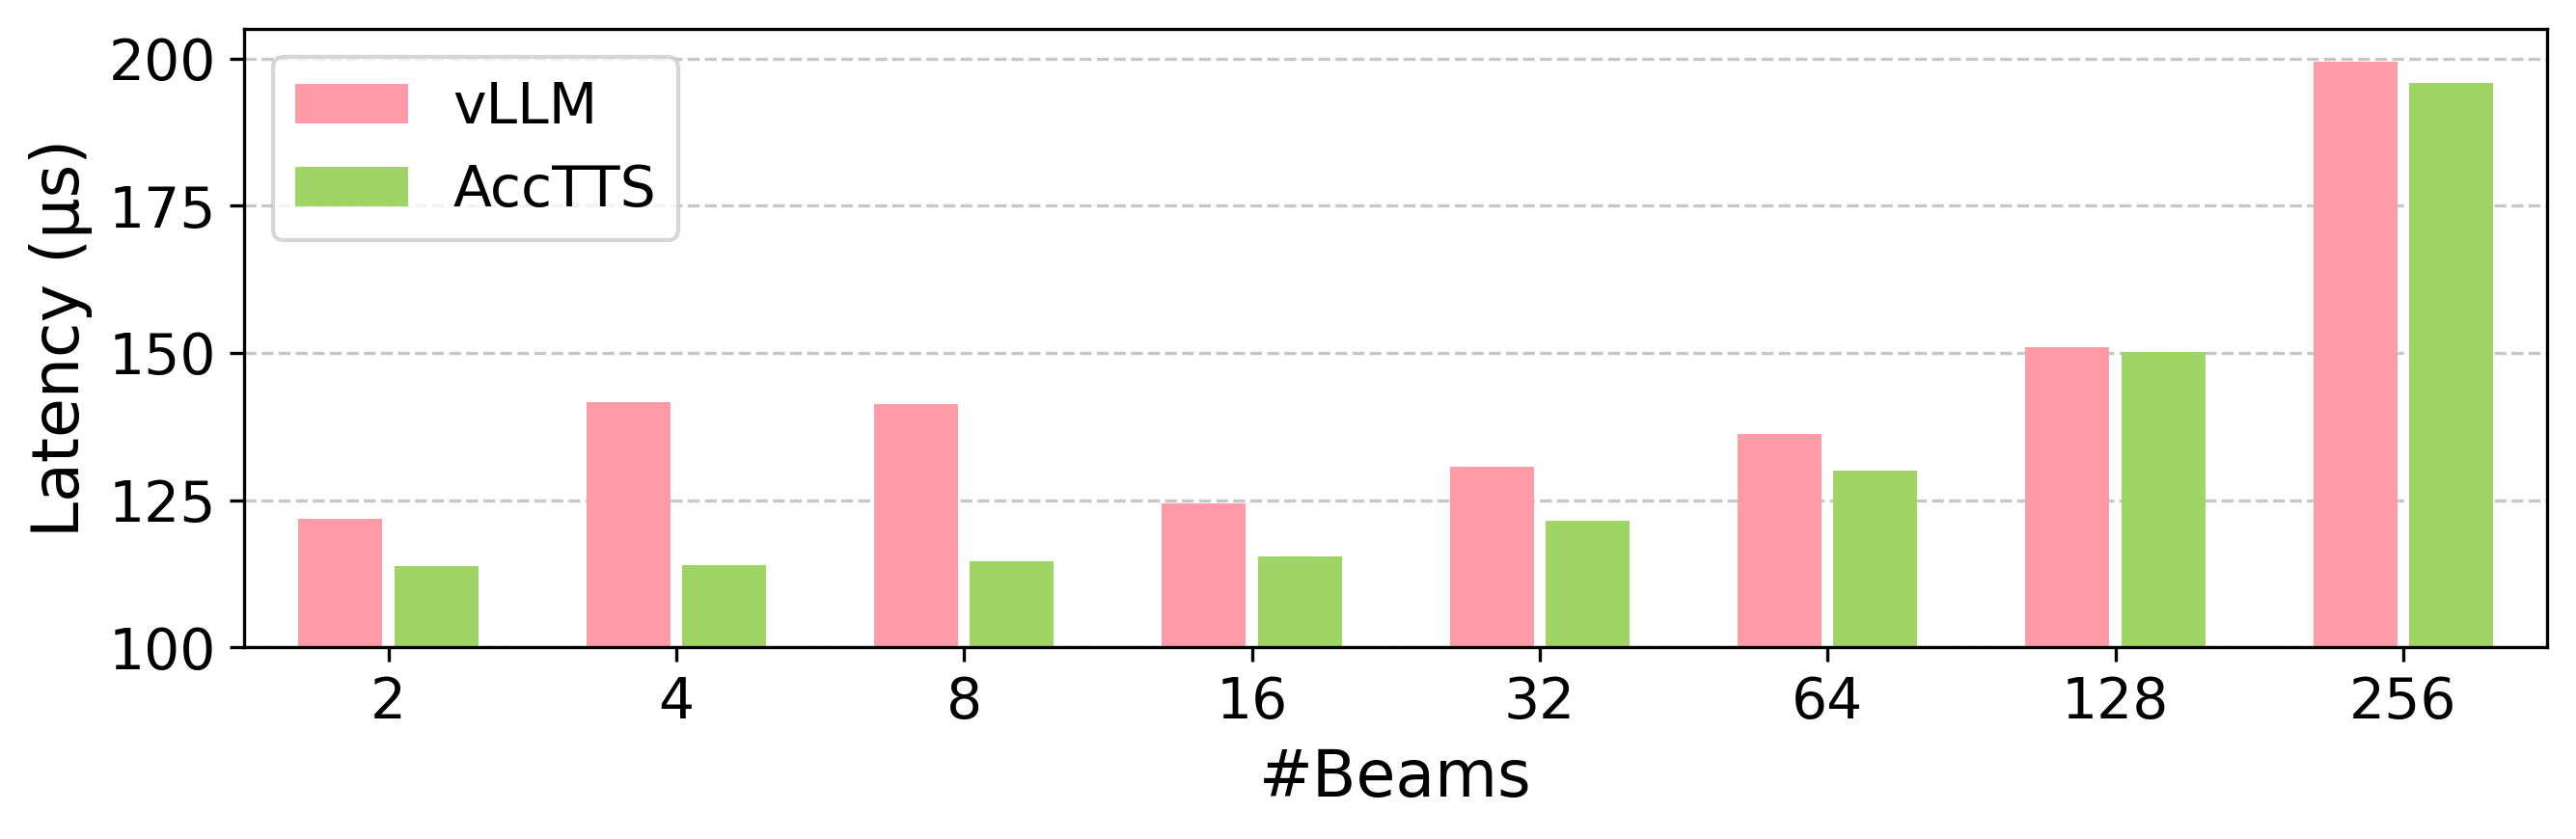

In [15]:
beam_labels = list(df.columns)           # ['2','4',...,'256']
vllm_runtime = df.loc["vLLM"].to_numpy()
acctts_runtime = df.loc["AccTTS"].to_numpy()

# Per-group footprint: two bars + intra-group gap; spacing across groups adds GROUP_GAP.
group_step = 2 * BAR_WIDTH + BAR_GAP + GROUP_GAP
group_centers = np.arange(len(beam_labels)) * group_step
left_x = group_centers - (BAR_WIDTH + BAR_GAP) / 2
right_x = group_centers + (BAR_WIDTH + BAR_GAP) / 2

fig, ax = plt.subplots(figsize=FIG_SIZE, dpi=FIG_DPI)

ax.bar(left_x, vllm_runtime, width=BAR_WIDTH, color=COLOR_VLLM, label="vLLM")
ax.bar(right_x, acctts_runtime, width=BAR_WIDTH, color=COLOR_ACCTTS, label="AccTTS")

ax.set_xticks(group_centers)
ax.set_xticklabels(beam_labels, fontsize=FONTSIZE_XTICKS)
ax.tick_params(axis="y", labelsize=FONTSIZE_YTICKS)

ax.set_xlabel("#Beams", fontsize=16)
ax.set_ylabel("Latency (\u03bcs)", fontsize=16)

ax.set_ylim(*Y_RANGE)
ax.set_xlim(
    group_centers[0] - (BAR_WIDTH + BAR_GAP / 2 + GROUP_GAP / 2),
    group_centers[-1] + (BAR_WIDTH + BAR_GAP / 2 + GROUP_GAP / 2),
)

# Dashed horizontal grid lines.
ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_axisbelow(True)

ax.legend(fontsize=FONTSIZE_LEGEND, frameon=True, loc="upper left")

fig.tight_layout()
fig.savefig(OUT_PNG, bbox_inches="tight")
print(f"saved -> {OUT_PNG}")
plt.show()